# Fitting coherent T1/T2 decay
Run cells in order. Configure paths and switches in cell 1.

## 1. Data loading and plotting

c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 6 processed NPZ datasets; beta_scale=1.0.


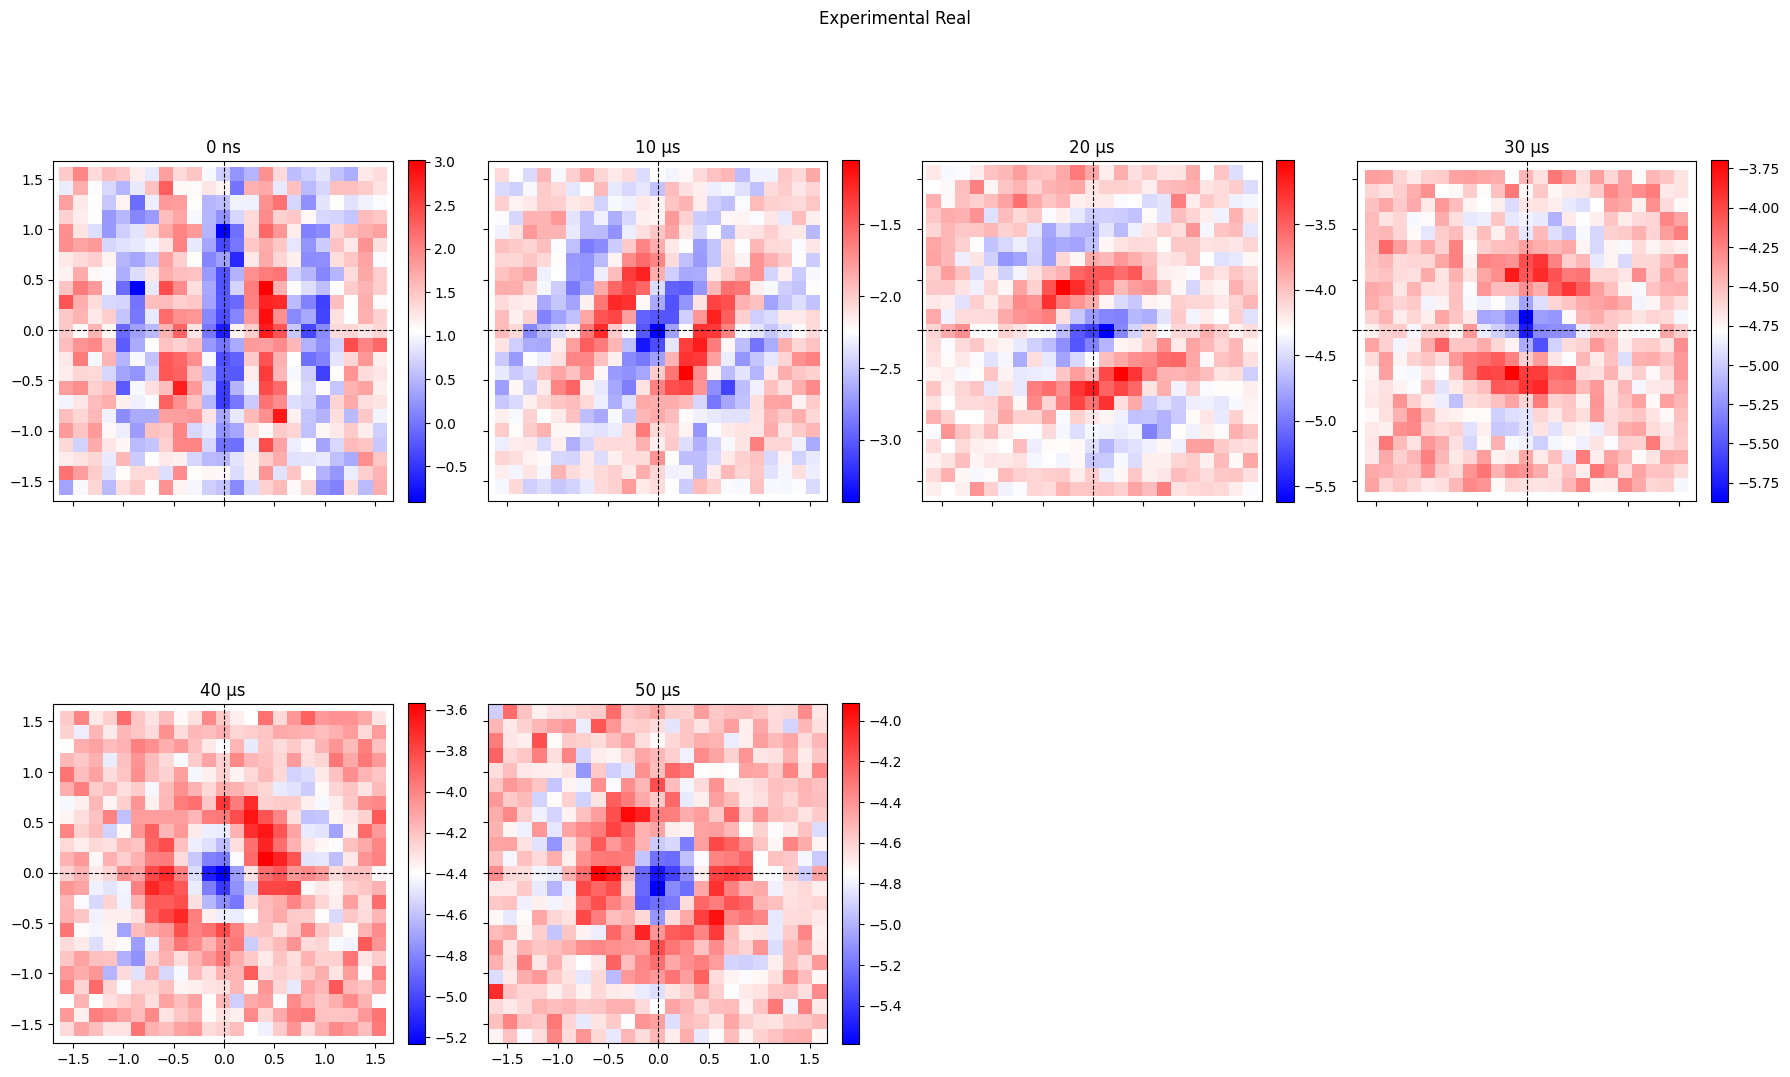

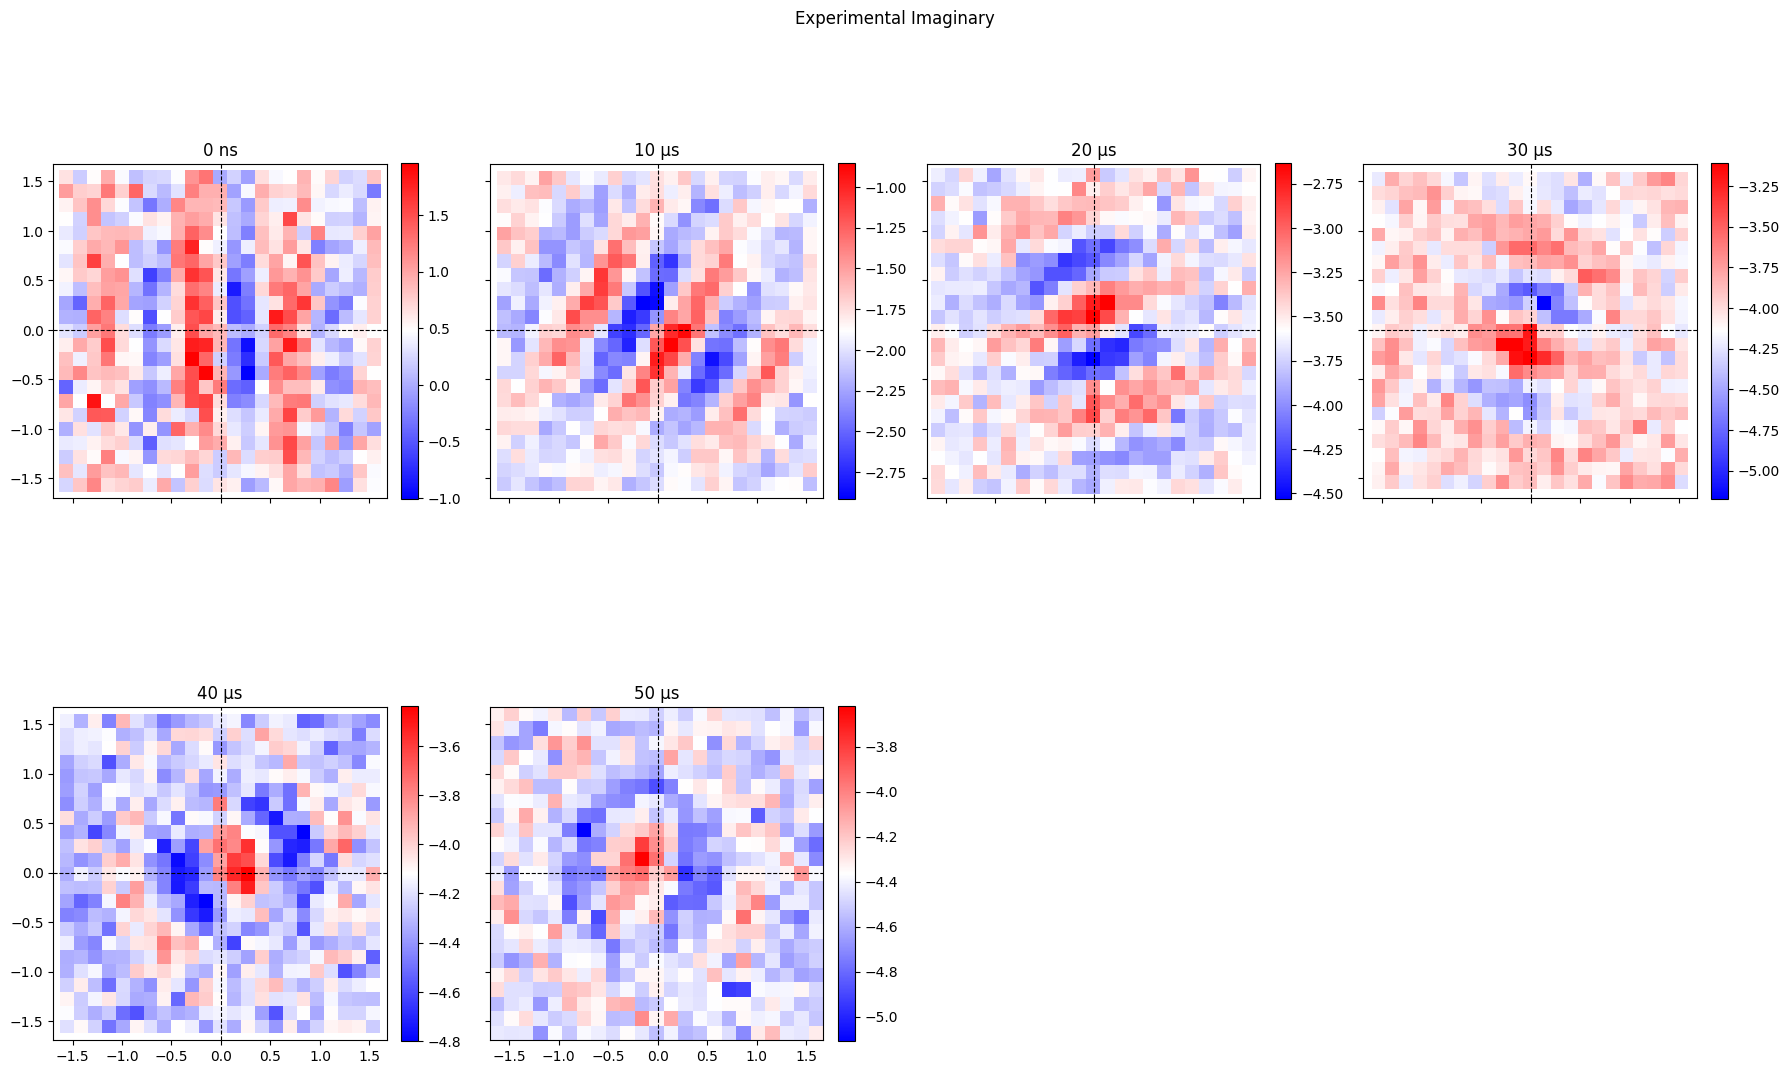

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from helpers.io import load_experiment, load_processed_npz
from helpers.plotting import plot_characteristic_functions, plot_landscape
from helpers.simulation import CharacteristicFunctionSimulator
from helpers.comparison import build_mask, residue, residue_no_rotation, compare_experiment_simulation, extract_rotation_angles, build_time_weights
from helpers.fitting import find_best_alpha
from helpers.optimizer import optimize_parameters
postprocess = True
fit_first_independent = True
time_weight_exponent = 0.0
Real_part, Imag_part = True, True
if not (Real_part or Imag_part): raise ValueError('Select at least one component.')

if postprocess:
    # Processed NPZ files already contain calibrated beta axes.
    processed_data_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_3'
    delay_times_ns = np.array([0, 10_000, 20_000, 30_000, 40_000, 50_000], dtype=float)
    DELAY_INDICES = 'all'
    beta_scale = 1.0
    state_list_real, state_list_imag, x_list, y_list, decay_sweep_sorted = load_processed_npz(processed_data_dir, delay_times_ns, DELAY_INDICES, beta_scale)
    print(f'Loaded {len(decay_sweep_sorted)} processed NPZ datasets; beta_scale={beta_scale}.')
else:
    # Original raw HDF5 loading path.
    beta_scale, experiment_start = 2.0, '20-01-00'
    real_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_real' if Real_part else None
    imag_dir = r'E:\\CQT\\Fast Flux\\fitting_coherent_decay\\data_1\\data_imag' if Imag_part else None
    real_decays = np.array([4,7000,14000,21000])*4 if Real_part else None
    imag_decays = np.array([4,7000,14000,21000])*4 if Imag_part else None
    state_list_real, state_list_imag, x_list, y_list, decay_sweep_sorted = load_experiment(real_dir, imag_dir, real_decays, imag_decays, beta_scale, experiment_start)
independent_first = postprocess and fit_first_independent
weights = build_time_weights(decay_sweep_sorted, time_weight_exponent)

exp_data = (state_list_real,state_list_imag) if Real_part and Imag_part else (state_list_real if Real_part else state_list_imag)
if Real_part: plot_characteristic_functions(state_list_real,x_list,y_list,decay_sweep_sorted,'Experimental Real')
if Imag_part: plot_characteristic_functions(state_list_imag,x_list,y_list,decay_sweep_sorted,'Experimental Imaginary')

## 2. Simulation

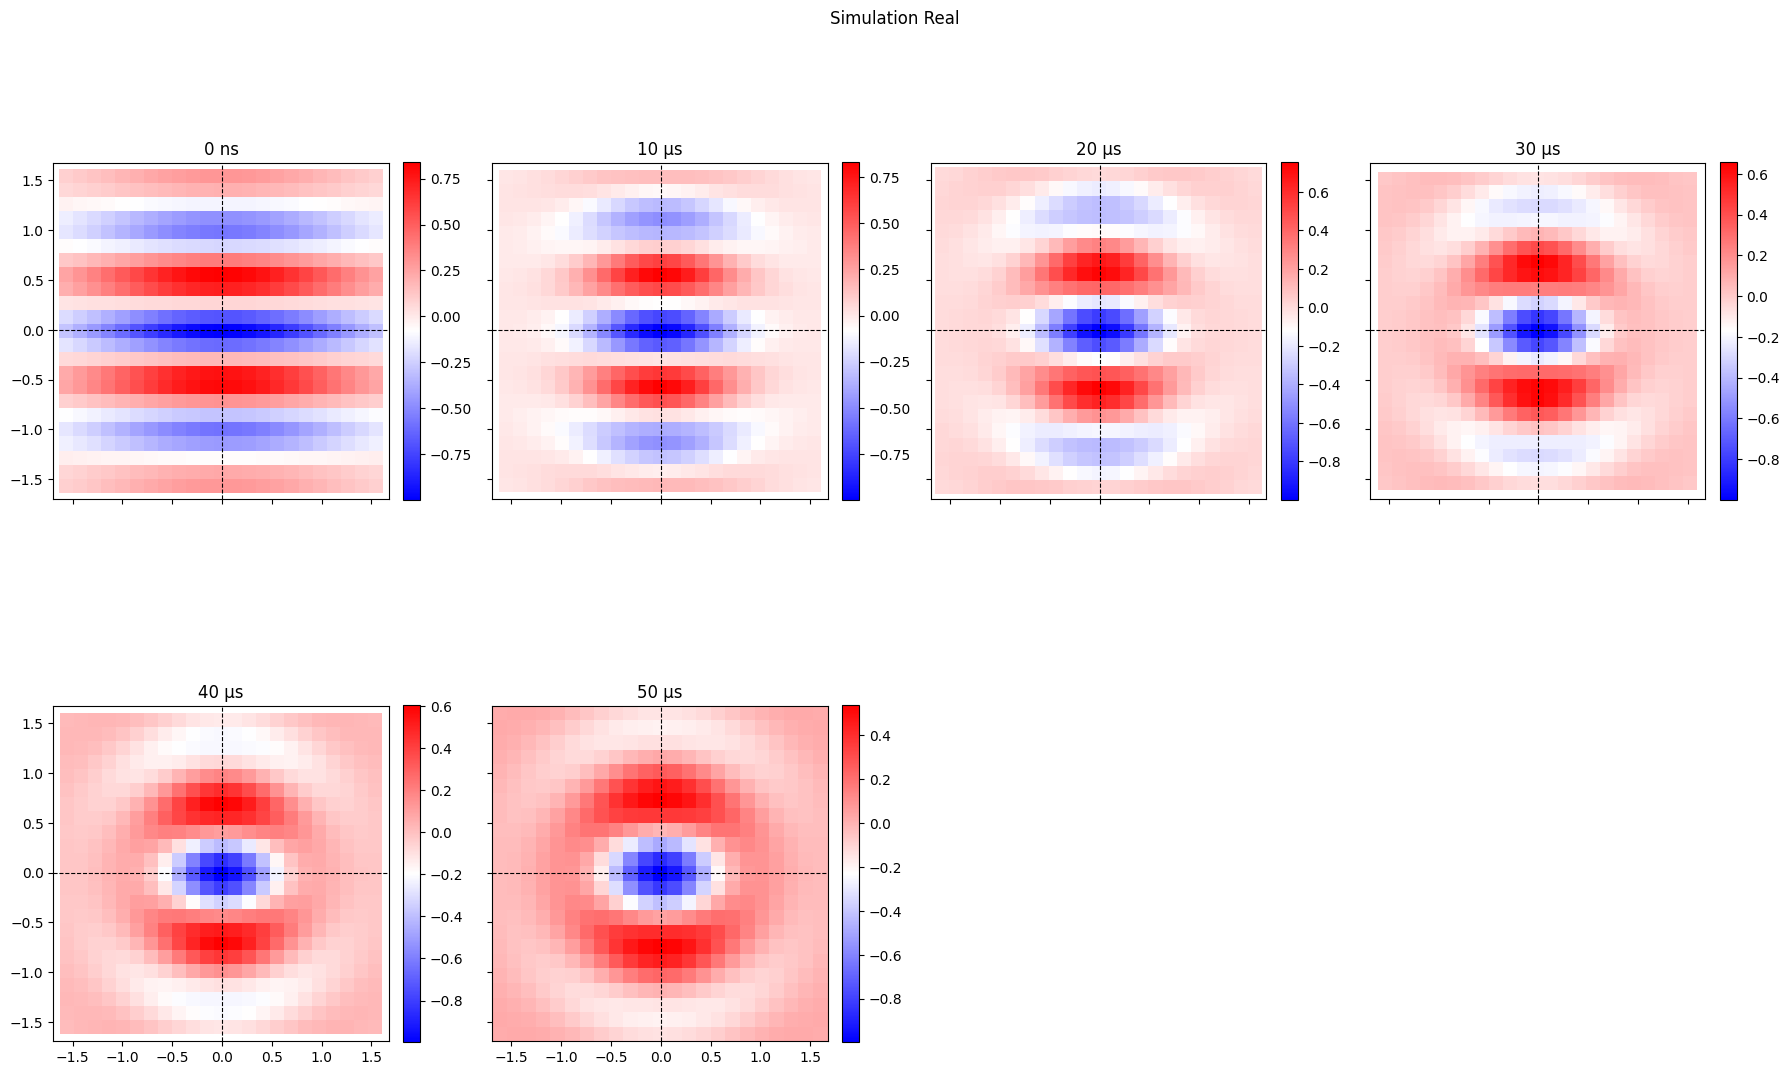

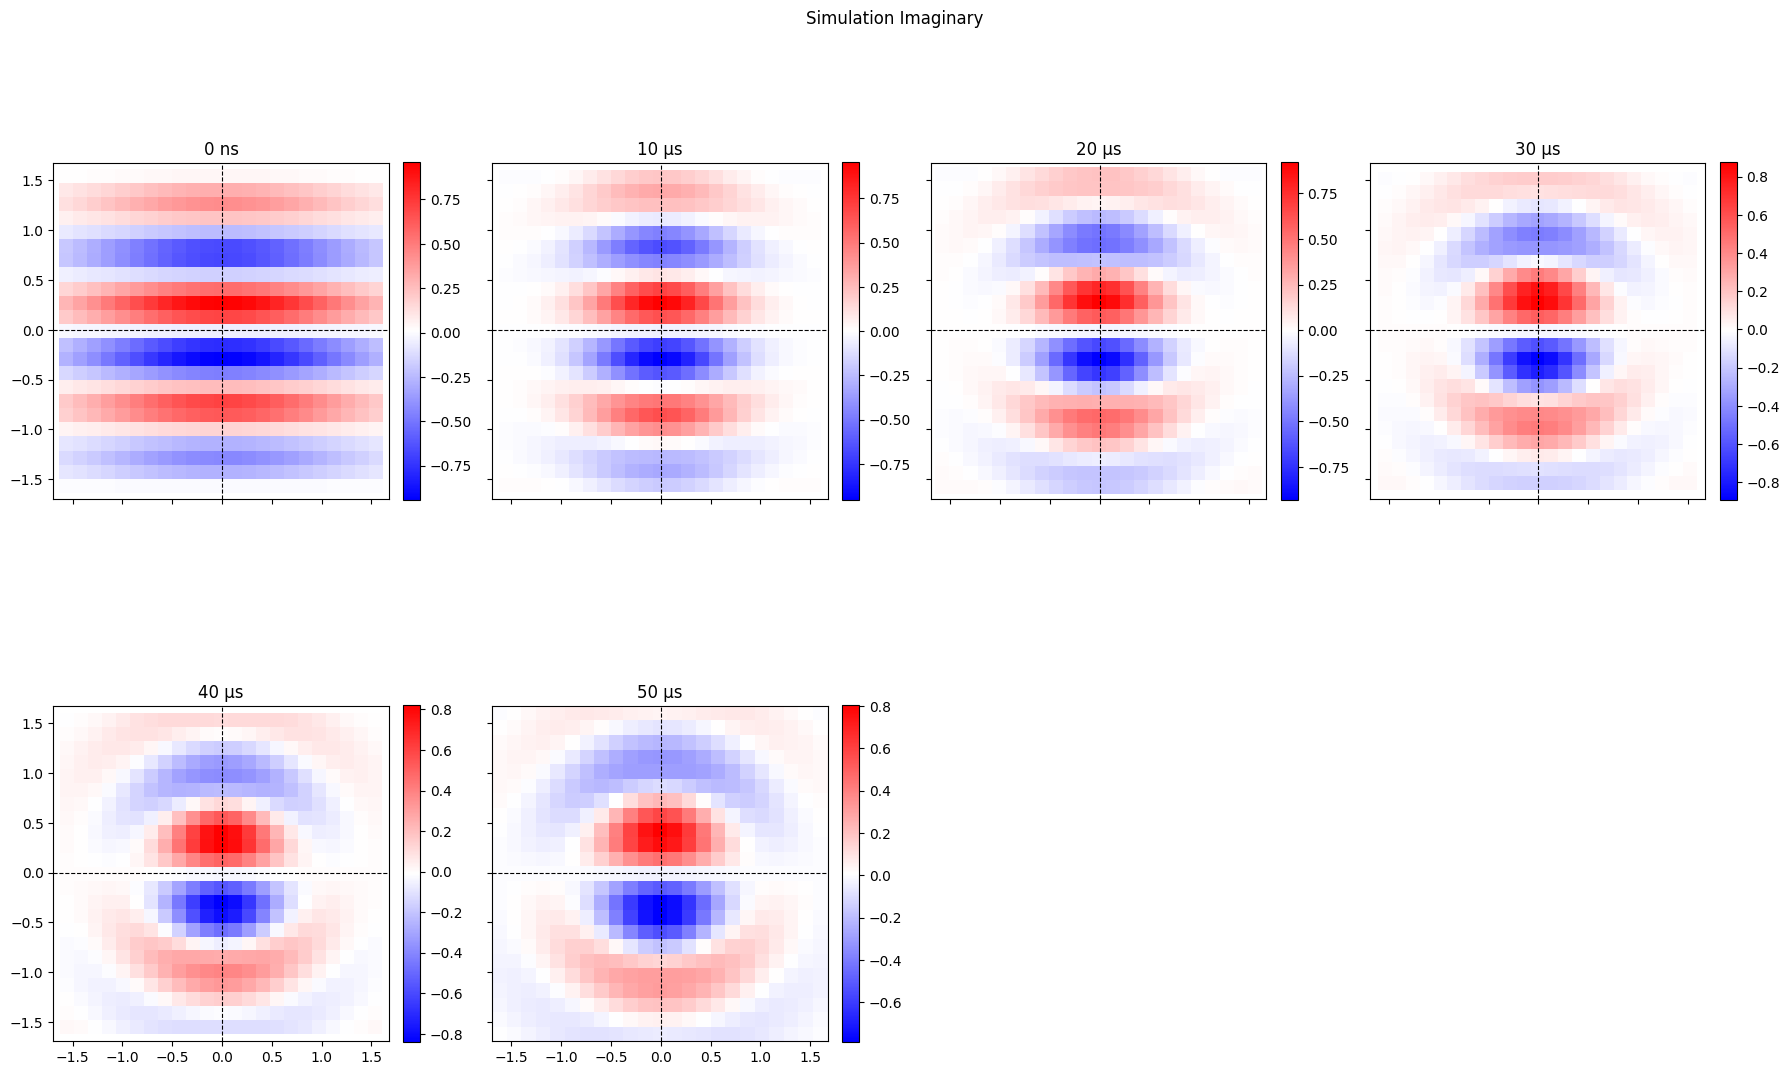

In [2]:
N_c = 50
simulator = CharacteristicFunctionSimulator(N_c,x_list[0],y_list[0])
T1, T2, alpha = 100_000, 100_000, 3.0
charfunc_sim = simulator.simulate(decay_sweep_sorted,T1,T2,alpha=alpha,return_real=Real_part,return_imag=Imag_part)
if Real_part: plot_characteristic_functions(charfunc_sim[0] if Imag_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Real')
if Imag_part: plot_characteristic_functions(charfunc_sim[1] if Real_part else charfunc_sim,x_list,y_list,decay_sweep_sorted,'Simulation Imaginary')

## 3. Fit alpha and rotation

Searching alpha...
alpha=3.3625, angle=88.00 deg, cost=0.268686


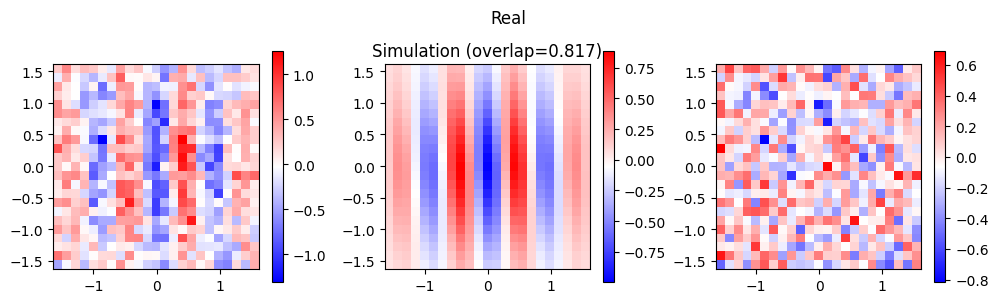

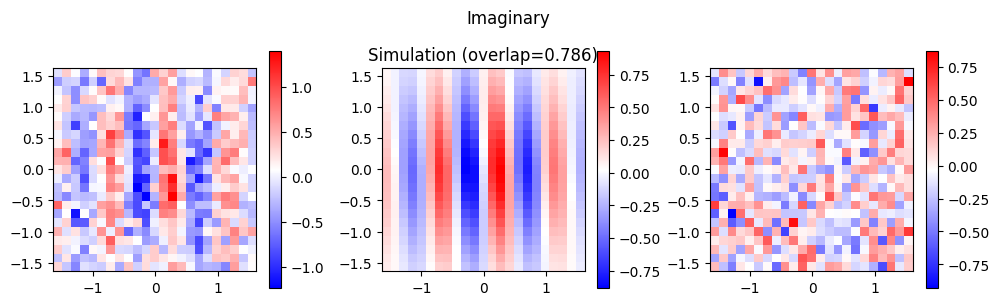

(array([88.]), array([0.81673687]))

In [3]:
mask = build_mask(x_list[0],y_list[0],2.5)
alpha_values = np.linspace(3.0,4.0,81); rotation_values = np.linspace(-180.0,180.0,361)
alpha_fit = find_best_alpha(simulator,exp_data,np.array([decay_sweep_sorted[0]]),alpha_values,rotation_values,mask,component=('real' if Real_part else 'imag'))
initial_alpha, initial_angle = alpha_fit['alpha'], alpha_fit['angle']
print(f'alpha={initial_alpha:.4f}, angle={initial_angle:.2f} deg, cost={alpha_fit["cost"]:.6f}')
alpha_exp_data = (state_list_real[:1], state_list_imag[:1]) if Real_part and Imag_part else (state_list_real[:1] if Real_part else state_list_imag[:1])
compare_experiment_simulation(alpha_exp_data,alpha_fit['sim'],x_list[:1],y_list[:1],mask,weights=weights[:1],rotate_images=True,rotation_angles=rotation_values,first_angle=(initial_angle if independent_first else None))

## 4. Coarse T1/T2 grid search

Grid result: T1=166.667 us, T2=138.889 us, residue=0.438581


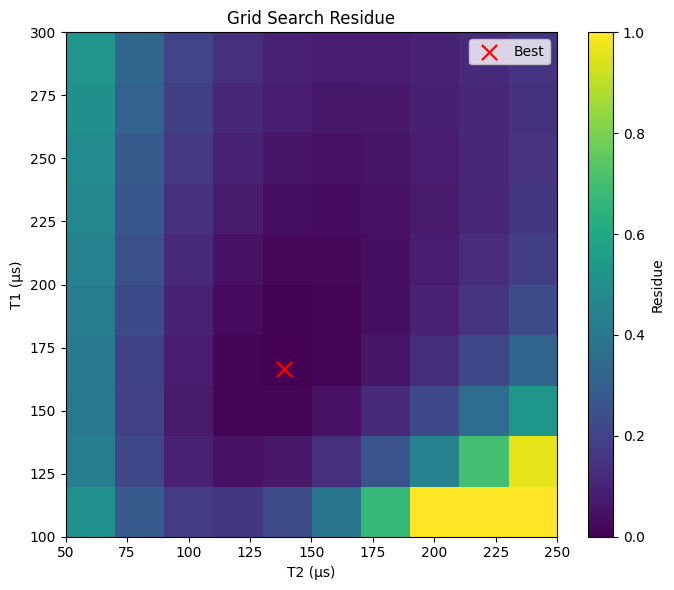

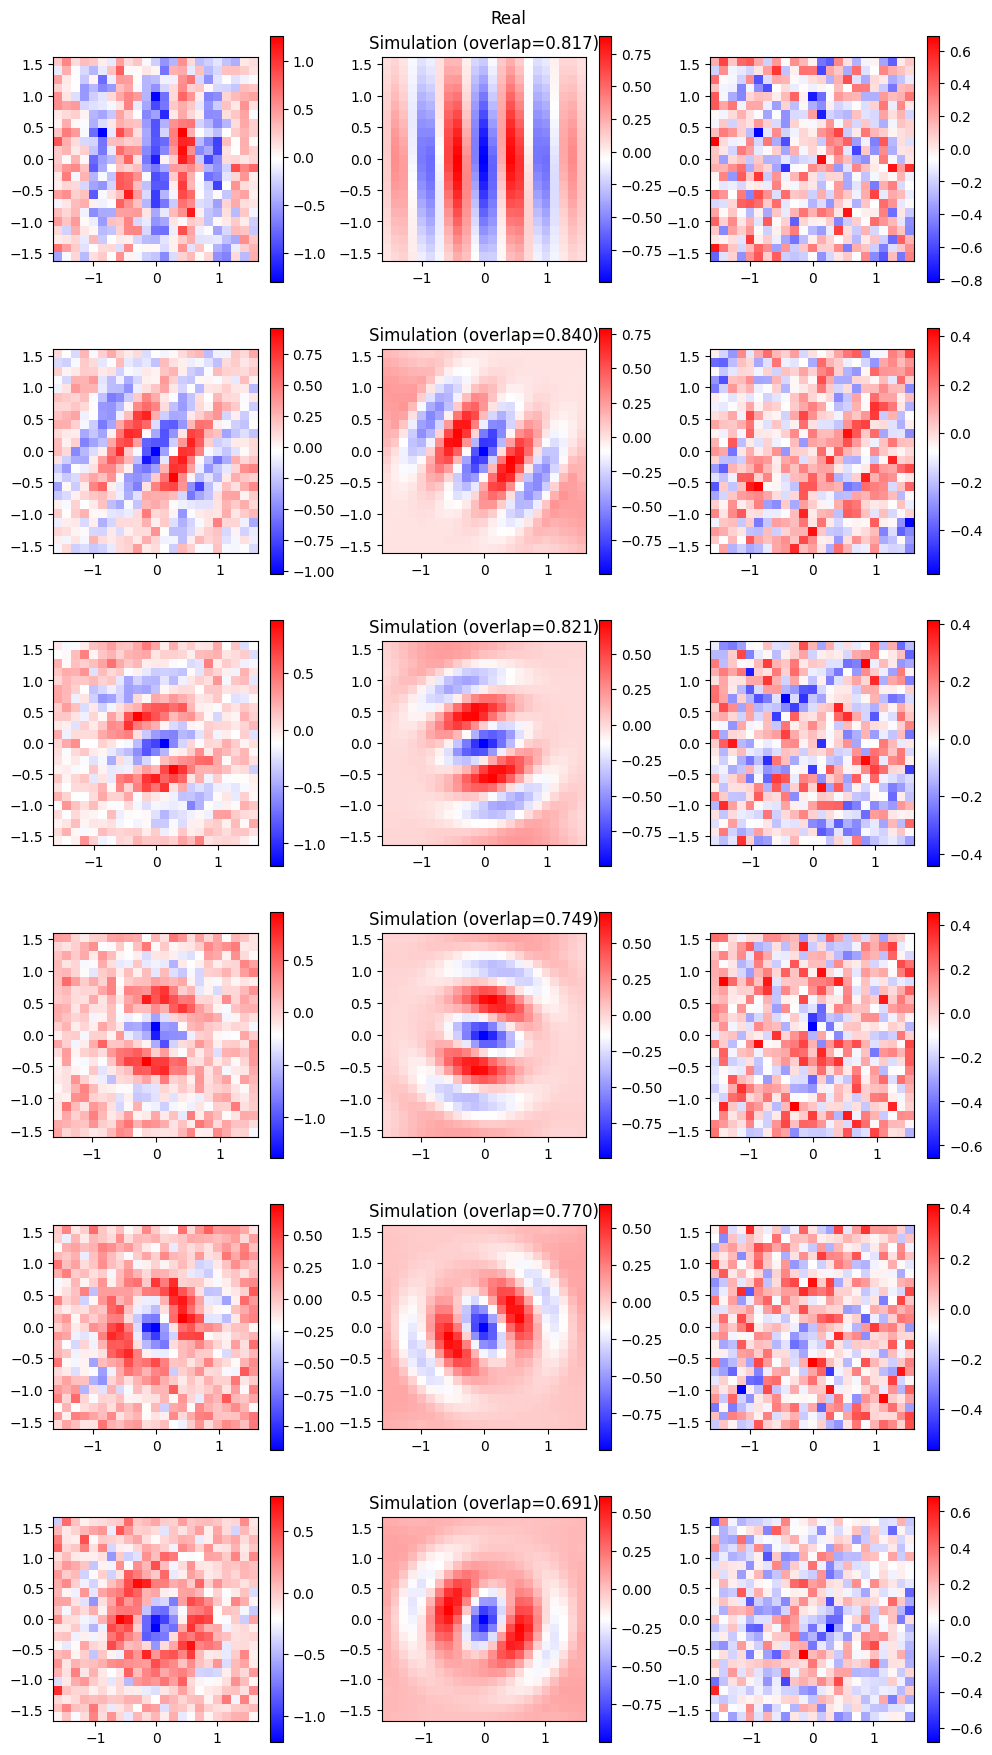

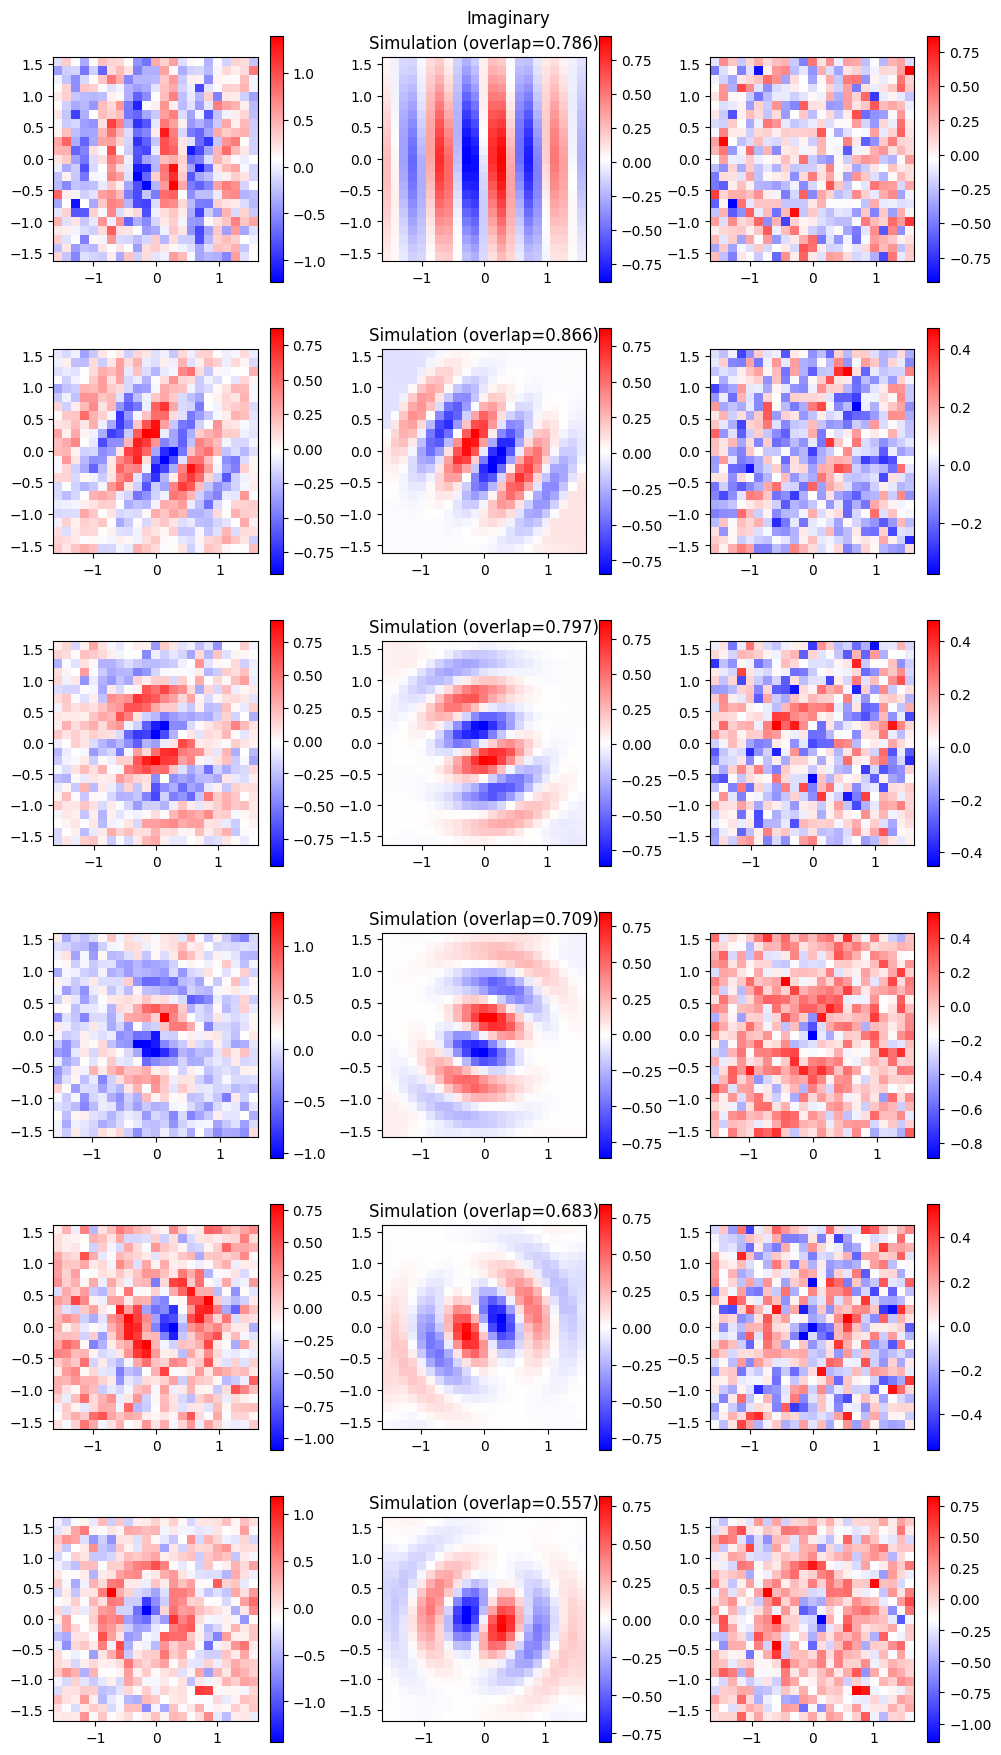

(array([ 88., 121., 160., 180.,  90., 111.]),
 array([0.81673687, 0.82251079, 0.82113002, 0.6713806 , 0.66545347,
        0.69142652]))

In [4]:
T1_values=np.linspace(100_000,300_000,10); T2_values=np.linspace(50_000,250_000,10)
cost=np.empty((len(T1_values),len(T2_values)))
for i,t1 in enumerate(T1_values):
    for j,t2 in enumerate(T2_values):
        sim=simulator.simulate(decay_sweep_sorted,t1,t2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
        cost[i,j]=residue(exp_data,sim,mask,weights=weights,first_angle=(initial_angle if independent_first else None))
best=np.unravel_index(np.argmin(cost),cost.shape); best_T1,best_T2=T1_values[best[0]],T2_values[best[1]]
best_sim=simulator.simulate(decay_sweep_sorted,best_T1,best_T2,alpha=initial_alpha,return_real=Real_part,return_imag=Imag_part)
best_angles,best_overlaps=extract_rotation_angles(exp_data,best_sim,mask,first_angle=(initial_angle if independent_first else None))
print(f'Grid result: T1={best_T1/1000:.3f} us, T2={best_T2/1000:.3f} us, residue={cost[best]:.6f}')
plot_landscape(cost,T1_values,T2_values,best_T1,best_T2)
compare_experiment_simulation(exp_data,best_sim,x_list,y_list,mask,weights=weights,rotate_images=True,first_angle=(initial_angle if independent_first else None))

## 5. Estimate detuning

C:\Users\hecto\AppData\Local\Temp\ipykernel_27140\1352738612.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,_=curve_fit(angle_model,fit_times,fit_angles); initial_angle_offset,initial_detuning=popt[0],popt[1]/360.0


first-point angle=88.000 deg; prepared-state angle=82.000 deg, detuning=0.010833 MHz


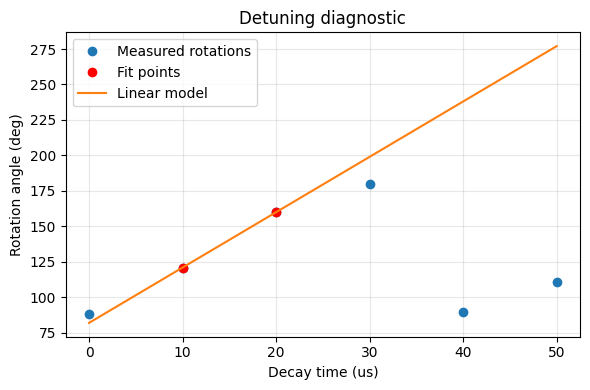

In [5]:
num_points_fit=2; times_us=np.asarray(decay_sweep_sorted)/1000.0
detuning_start = 1 if independent_first else 0
if len(best_angles) - detuning_start < 2: raise ValueError('At least two post-alpha-fit points are required to estimate detuning.')
fit_times=times_us[detuning_start:detuning_start+num_points_fit]
fit_angles=best_angles[detuning_start:detuning_start+num_points_fit].copy()
for i in range(len(fit_angles)):
    while fit_angles[i]-fit_angles[0]>180: fit_angles[i]-=360
    while fit_angles[i]-fit_angles[0]<-180: fit_angles[i]+=360
def angle_model(t,offset,slope): return offset+slope*t
popt,_=curve_fit(angle_model,fit_times,fit_angles); initial_angle_offset,initial_detuning=popt[0],popt[1]/360.0
if independent_first:
    print(f'first-point angle={initial_angle:.3f} deg; prepared-state angle={initial_angle_offset:.3f} deg, detuning={initial_detuning:.6f} MHz')
else:
    print(f'angle offset={initial_angle_offset:.3f} deg, detuning={initial_detuning:.6f} MHz')
plt.figure(figsize=(6,4)); plt.plot(times_us,best_angles,'o',label='Measured rotations'); plt.plot(fit_times,fit_angles,'ro',label='Fit points'); plt.plot(times_us,angle_model(times_us,*popt),'-',label='Linear model'); plt.xlabel('Decay time (us)'); plt.ylabel('Rotation angle (deg)'); plt.title('Detuning diagnostic'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

## 6. Final optimization

Optimizing T1/T2: 100%|██████████| 40/40 [00:10<00:00,  3.20it/s]e:\CQT\Fast Flux\coherent_decay_analysis\helpers\optimizer.py:37: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(tracked_objective, guess, method="Nelder-Mead",
Optimizing T1/T2: 100%|██████████| 40/40 [00:19<00:00,  2.08it/s]


Final: T1=164.376 us, T2=154.194 us, detuning=0.011116 MHz, cost=0.411913


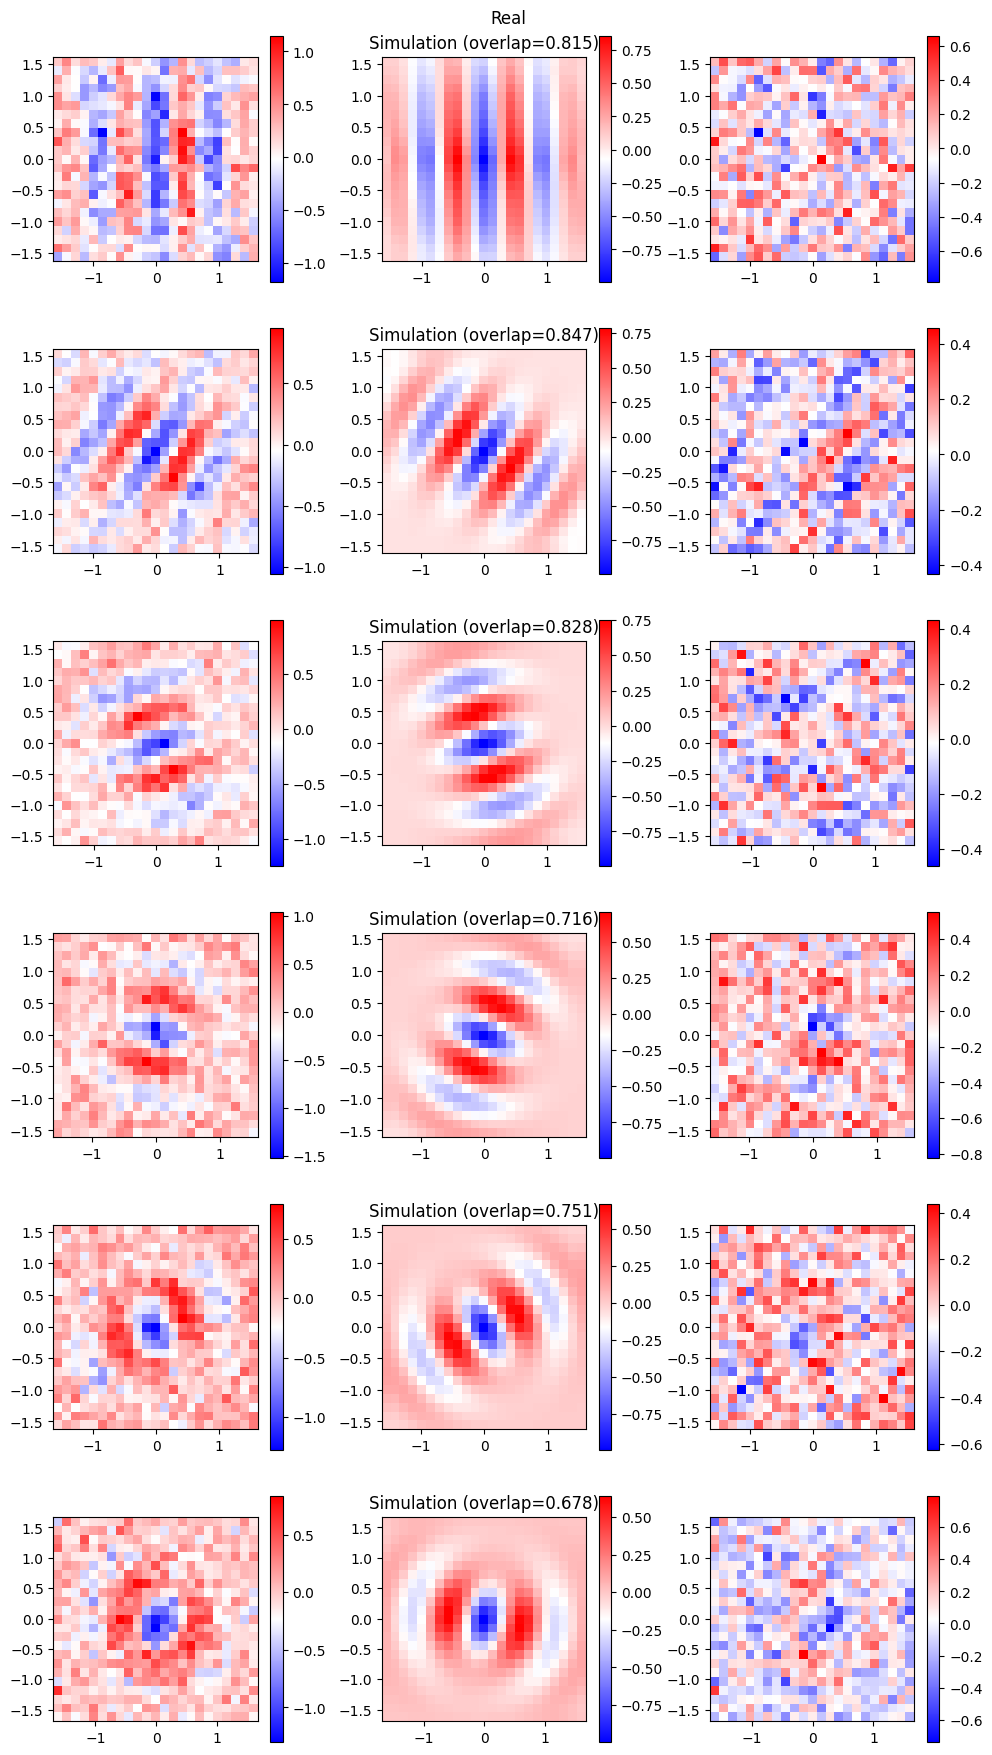

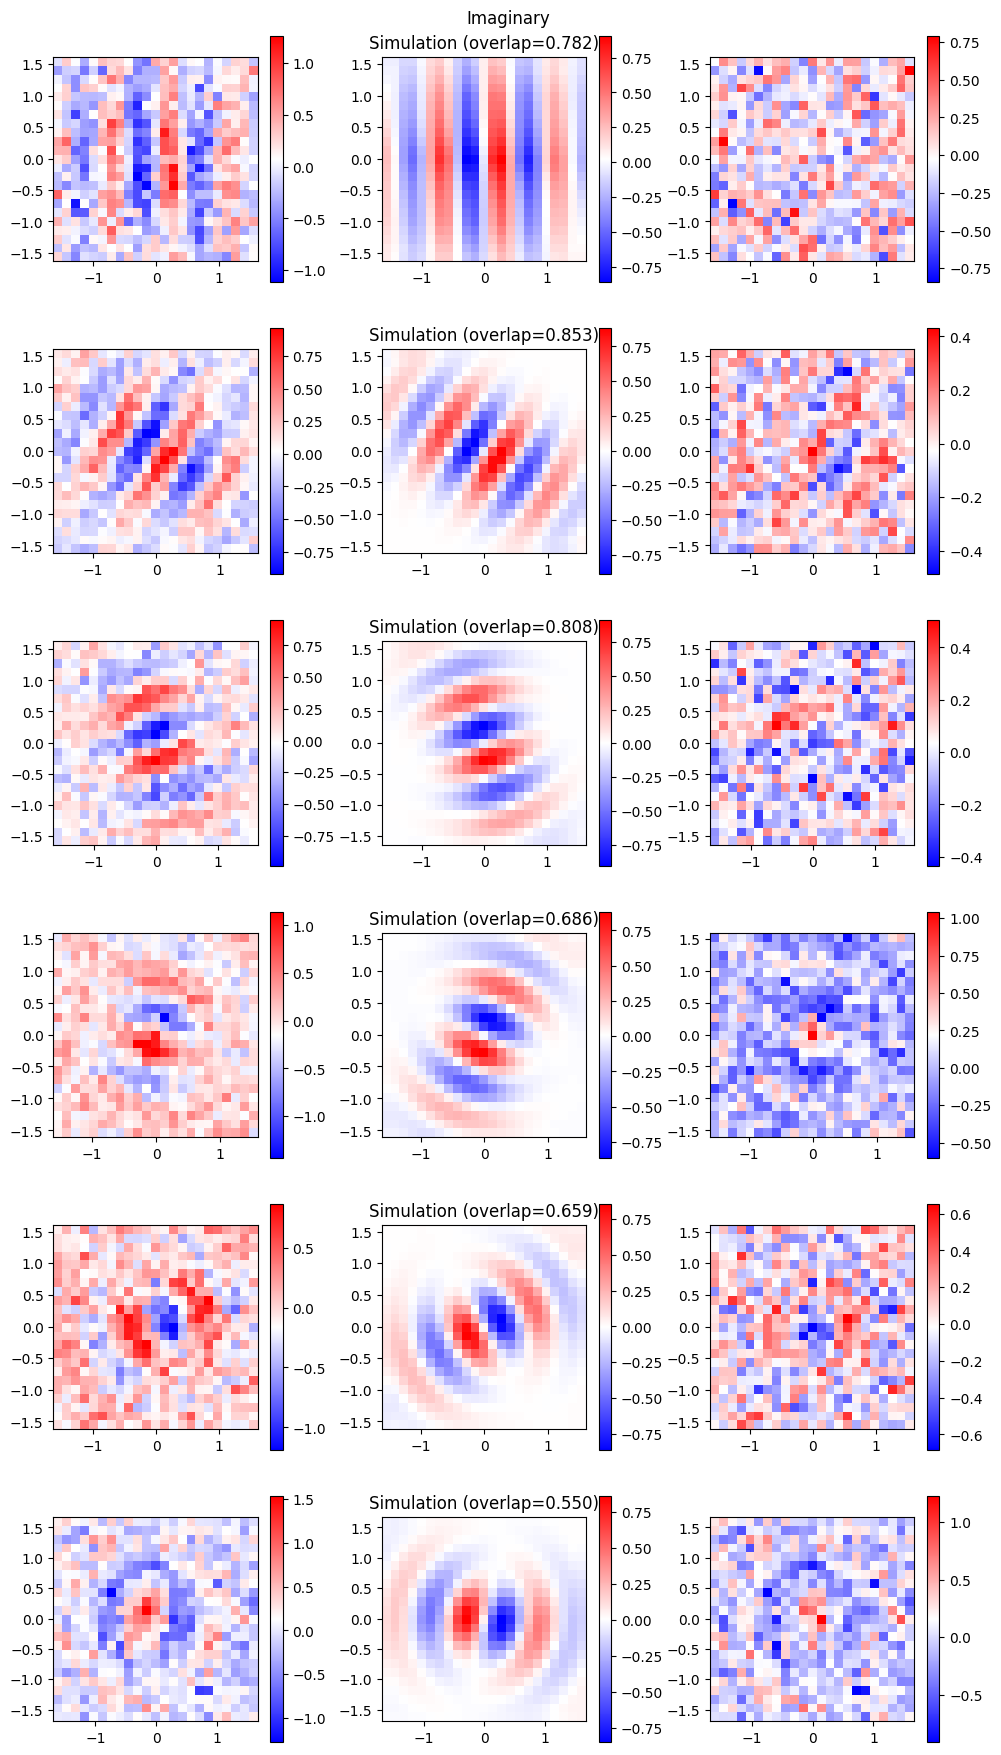

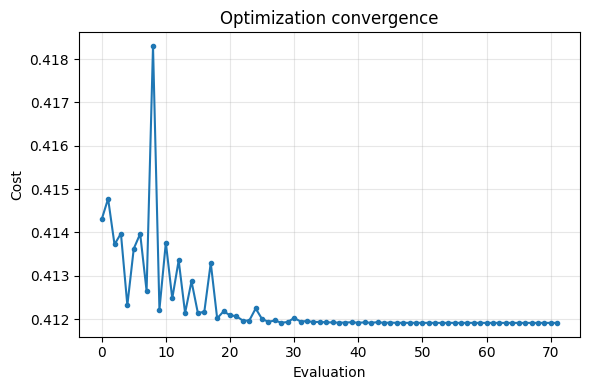

In [6]:
fit_T1=True; fixed_T1=300_000
fit=optimize_parameters(simulator,exp_data,decay_sweep_sorted,best_T1,best_T2,initial_detuning,initial_alpha,initial_angle_offset,lambda e,s,rotate_images=False: residue_no_rotation(e,s,mask,weights=weights),fit_T1=fit_T1,fixed_T1=fixed_T1,first_angle=(initial_angle if independent_first else None))
print(f'Final: T1={fit["T1"]/1000:.3f} us, T2={fit["T2"]/1000:.3f} us, detuning={fit["detuning"]:.6f} MHz, cost={fit["cost"]:.6f}')
compare_experiment_simulation(exp_data,fit['simulation'],x_list,y_list,mask,weights=weights,rotate_images=False)
if len(fit['history']):
    plt.figure(figsize=(6,4)); plt.plot(fit['history'][:,3],'-o',ms=3); plt.xlabel('Evaluation'); plt.ylabel('Cost'); plt.title('Optimization convergence'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()